# Task 2: Quantitative analysis using pynance and TaLib 
Objective: Load historical stock price data, compute financial technical indicators, and visualize the results to understand market behavior. 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import ta                        # technical analysis library
import warnings
warnings.filterwarnings('ignore')

### preparing the data
a. Load the stock price dataset into a pandas DataFrame  
b. Ensure columns are correctly typed (Open, High, Low, Close, Volume)  
c. Check for and handle missing values 

In [8]:
TICKER = 'AAPL'
#pick 4 year data for training and testing
START   = '2019-01-01'
END     = '2023-12-31'

DATA_PATH = '../data/raw/AAPL.csv'
df = pd.read_csv(DATA_PATH, index_col=0)

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)

print(f'Downloaded shape: {raw.shape}')
print(f'Columns (first level): {raw.columns.get_level_values(0).unique().tolist()}')
df.head(3)

Downloaded shape: (1258, 5)
Columns (first level): ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400


# Data cleaning and quality check

In [9]:
print('=== Missing values ===')
print(df.isnull().sum())

print(f'\nDuplicate dates: {df.index.duplicated().sum()}')

print('\n=== Descriptive Statistics ===')
df.describe().round(2)
df.shape
##no missing or null values, no duplicates, and the data looks good for further analysis

=== Missing values ===
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Duplicate dates: 0

=== Descriptive Statistics ===


(3774, 5)

## Technical Indicators with `ta` Library

Technical indicators are mathematical transformations of price/volume data used to identify trends, momentum, and potential reversals.


### Moving Averages (SMA & EMA)

**Simple Moving Average (SMA):**  
Average closing price over the last 20,50 etc days. All days weighted equally.

**Exponential Moving Average (EMA):**  
Like SMA but more recent days get higher weight. Reacts faster to price changes.  
Common windows: 20 days (short-term), 50 days (medium), 200 days (long-term trend).

In [15]:
# SMA
# # ta.trend.sma_indicator(series, window) returns a pandas Series of SMA values.
# The first (window-1) rows will be NaN because there isn't enough history yet.
df['SMA_20']  = ta.trend.sma_indicator(df['Close'], window=20)
df['SMA_50']  = ta.trend.sma_indicator(df['Close'], window=50)
df['SMA_200'] = ta.trend.sma_indicator(df['Close'], window=200)

# EMA 
df['EMA_12'] = ta.trend.ema_indicator(df['Close'], window=12)
df['EMA_26'] = ta.trend.ema_indicator(df['Close'], window=26)

print('Moving averages computed')
df[['Close','SMA_20','SMA_50','EMA_12']].tail(5).round(2)

Moving averages computed


,Close,SMA_20,SMA_50,EMA_12
Date,,,,
2023-12-22,191.79,191.86,183.57,192.92
2023-12-26,191.24,192.02,183.86,192.66
2023-12-27,191.34,192.15,184.15,192.46
2023-12-28,191.77,192.36,184.48,192.35
2023-12-29,190.73,192.49,184.81,192.10


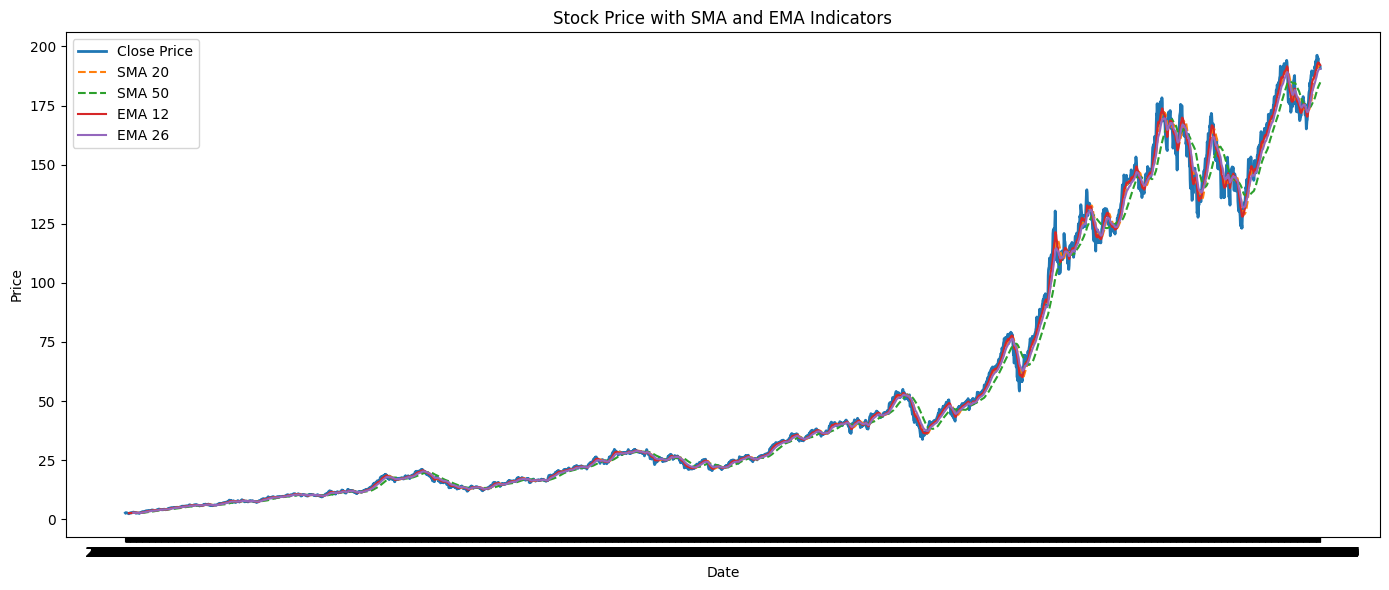

In [18]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Close'], label='Close Price', linewidth=2)

plt.plot(df.index, df['SMA_20'], label='SMA 20', linestyle='--')
plt.plot(df.index, df['SMA_50'], label='SMA 50', linestyle='--')

plt.plot(df.index, df['EMA_12'], label='EMA 12')
plt.plot(df.index, df['EMA_26'], label='EMA 26')

plt.title('Stock Price with SMA and EMA Indicators')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.tight_layout()
plt.show()

# Relative Strength Index

In [17]:
# RSIIndicator takes the Close series and the lookback window (default 14).
rsi_indicator = ta.momentum.RSIIndicator(close=df['Close'], window=14)
df['RSI_14'] = rsi_indicator.rsi()

print('RSI computed')
print(f'RSI range: {df["RSI_14"].min():.1f} – {df["RSI_14"].max():.1f}')
df[['Close','RSI_14']].tail(5).round(2)
print(df.columns)

RSI computed
RSI range: 21.0 – 90.7
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'SMA_200',
       'EMA_12', 'EMA_26', 'RSI_14'],
      dtype='str')


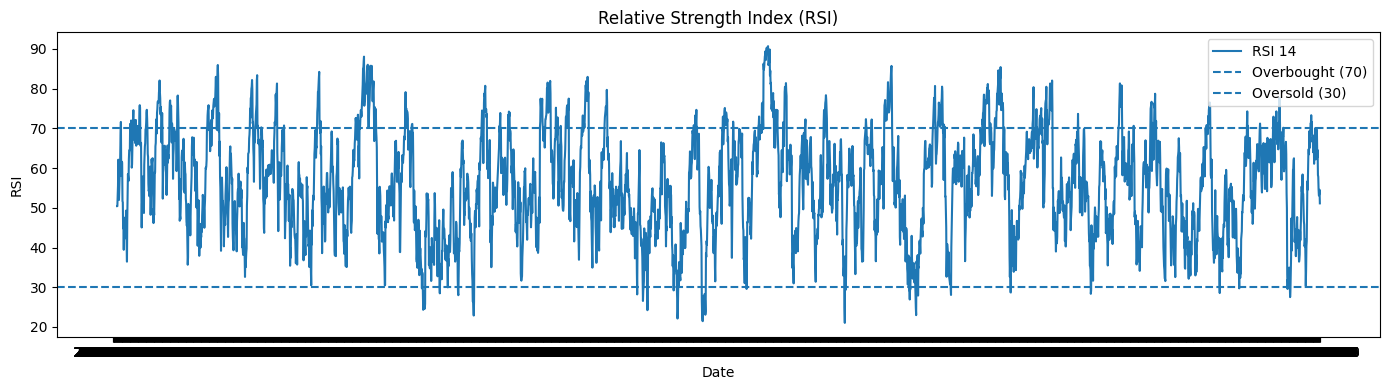

In [19]:
plt.figure(figsize=(14,4))

plt.plot(df.index, df['RSI_14'], label='RSI 14')

plt.axhline(70, linestyle='--', label='Overbought (70)')
plt.axhline(30, linestyle='--', label='Oversold (30)')

plt.title('Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')

plt.legend()

plt.tight_layout()
plt.show()

# Moving Average Convergence Divergence

In [22]:
macd = ta.trend.MACD(close=df['Close'])

df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()
df['MACD_diff'] = macd.macd_diff()

print('MACD computed ✅')
df[['Close','MACD','MACD_Signal','MACD_Hist']].tail(5).round(4)

MACD computed ✅


,Close,MACD,MACD_Signal,MACD_Hist
Date,,,,
2023-12-22,191.7888,2.6331,3.2353,-0.6021
2023-12-26,191.2439,2.3048,3.0492,-0.7444
2023-12-27,191.3430,2.0291,2.8451,-0.8160
2023-12-28,191.7690,1.8240,2.6409,-0.8169
2023-12-29,190.7288,1.5595,2.4246,-0.8651


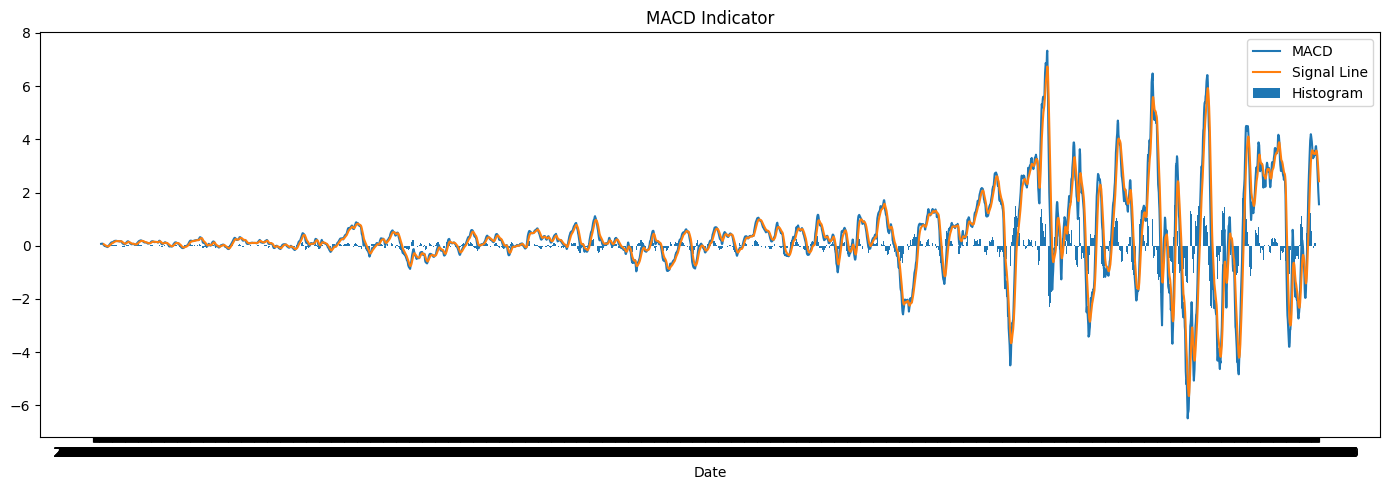

In [23]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df['MACD'], label='MACD')
plt.plot(df.index, df['MACD_signal'], label='Signal Line')

plt.bar(df.index, df['MACD_diff'], label='Histogram')

plt.title('MACD Indicator')
plt.xlabel('Date')

plt.legend()

plt.tight_layout()
plt.show()